# TP1 - Classification de texte - Amazon_Unlocked_Mobile

### Importation des librairies

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
import tensorflow as tf
from tensorflow import keras
from keras import layers
from keras import activations
from keras import losses
from keras import optimizers
from keras import metrics
from sklearn.preprocessing import LabelEncoder


### Chargement des données

In [43]:
trainDataset = pd.read_csv("http://www.i3s.unice.fr/~riveill/dataset/Amazon_Unlocked_Mobile/train.csv.gz")
valDataset = pd.read_csv("http://www.i3s.unice.fr/~riveill/dataset/Amazon_Unlocked_Mobile/val.csv.gz")
testDataset = pd.read_csv("http://www.i3s.unice.fr/~riveill/dataset/Amazon_Unlocked_Mobile/test.csv.gz")

### Prétraitement des données

In [47]:
X_train = trainDataset['Reviews'].astype(str)
y_train = trainDataset['Rating']
X_val = valDataset['Reviews'].astype(str)
y_val = valDataset['Rating']
X_test = testDataset['Reviews'].astype(str)
y_test = testDataset['Rating']

### Ajustement des labels
Plage de valeur de 0 à 4 compris au lieu de 1 à 5 compris

In [48]:
y_train = y_train - 1
y_val = y_val - 1
y_test = y_test - 1

Nombre de classe différente

In [49]:
nbClass = len(np.unique(y_train))

### Création du modèle


In [50]:
vectorizer = layers.TextVectorization(output_mode='tf_idf', split="whitespace", ngrams=None, standardize="lower") #jusqu'à 10 mots
vectorizer.adapt(X_train)

In [67]:
input_text = keras.Input(shape=(1,), dtype=tf.string)
x = vectorizer(input_text)
x = layers.Dense(32, activation=activations.relu)(x)
x = layers.Dropout(0.5)(x)
x = layers.Dense(32, activation=activations.relu)(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(nbClass, activation=activations.softmax)(x)

In [68]:
model = keras.Model(inputs=input_text, outputs=output)

In [69]:
model.compile(optimizer=optimizers.Adam(), loss=losses.sparse_categorical_crossentropy, metrics=["accuracy"])

In [70]:
early_stopping = keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)

### Entraînement du modèle

In [71]:
history = model.fit(X_train, y_train, epochs=20, validation_data=(X_val, y_val), callbacks=[early_stopping])

Epoch 1/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 8s 41ms/step - accuracy: 0.4004 - loss: 1.5251 - val_accuracy: 0.5720 - val_loss: 1.1566
Epoch 2/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step - accuracy: 0.5847 - loss: 1.1469 - val_accuracy: 0.6310 - val_loss: 1.0000
Epoch 3/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 35ms/step - accuracy: 0.6337 - loss: 0.9737 - val_accuracy: 0.6750 - val_loss: 0.9239
Epoch 4/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 37ms/step - accuracy: 0.6804 - loss: 0.8561 - val_accuracy: 0.6810 - val_loss: 0.8974
Epoch 5/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.7066 - loss: 0.7759 - val_accuracy: 0.6860 - val_loss: 0.9175
Epoch 6/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 38ms/step - accuracy: 0.7332 - loss: 0.7017 - val_accuracy: 0.6820 - val_loss: 0.9007
Epoch 7/20
157/157 ━━━━━━━━━━━━━━━━━━━━ 6s 36ms/step - accuracy: 0.7624 - loss: 0.6452 - val_accuracy: 0.6820 - val_loss: 0.9099


### Evaluation du modèle

In [72]:
loss, accuracy = model.evaluate(X_test, y_test)
print(f"Loss: {loss}, Accuracy: {accuracy}")

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.6703 - loss: 0.9259
Loss: 0.943454384803772, Accuracy: 0.6620000004768372


### Affichage des courbes d'apprentissage

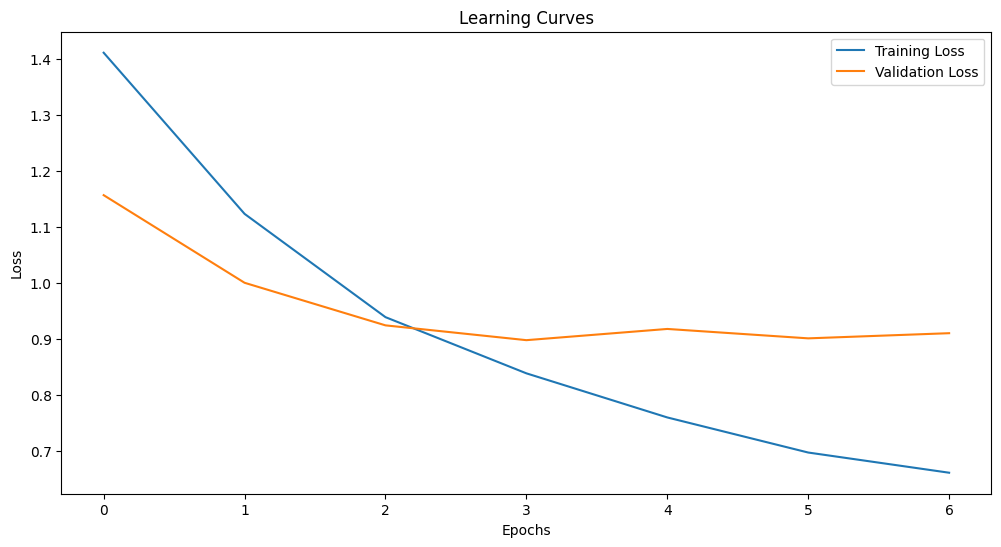

In [73]:
plt.figure(figsize=(12, 6))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Learning Curves')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

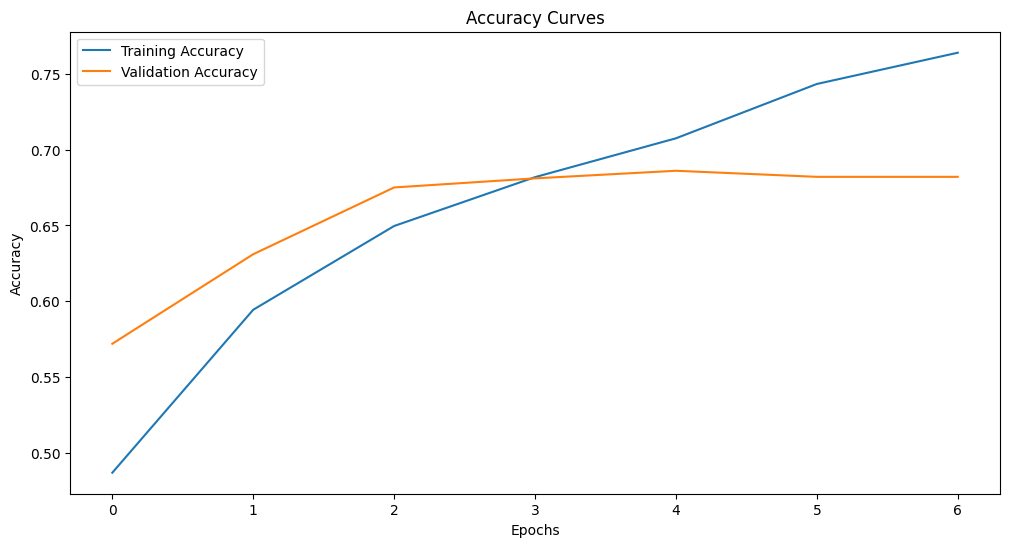

In [74]:
model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.001), loss='binary_crossentropy', metrics=['accuracy'])
plt.figure(figsize=(12, 6))
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Accuracy Curves')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

Analyse: trivial cf. voir cours